###Importing all relevant libraries

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import MNIST
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from torch.optim import SGD, AdamW
from sklearn.metrics import accuracy_score, classification_report
torch.manual_seed(123)

In [ ]:
#Set the system device
device = "cuda" if torch.cuda.is_available() else "cpu"
print("System device: {}".format(device))

System device: cuda


In [ ]:
#Loading and preprocessing the dataset
mnist_root_dir = "main/mnist"
mnist_dataset_train = MNIST(mnist_root_dir, train = True, download = True)
mnist_dataset_val = MNIST(mnist_root_dir, train = False, download = True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 494kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.53MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.60MB/s]


In [ ]:
#Dividing the dataset into training and validation sets
train_images = mnist_dataset_train.data
train_targets = mnist_dataset_train.targets
val_images = mnist_dataset_val.data
val_targets = mnist_dataset_val.targets

In [ ]:
train_targets_count = len(train_targets)
train_targets_unique = len(set(mnist_dataset_train.classes))
print("Train targets count: {}\n Unique train targets: {}".format(
    train_targets_count,
    train_targets_unique
))

Train targets count: 60000
 Unique train targets: 10


In [ ]:
#Displaying all the classes found in the dataset
target_classes = mnist_dataset_train.classes
print(target_classes)

['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


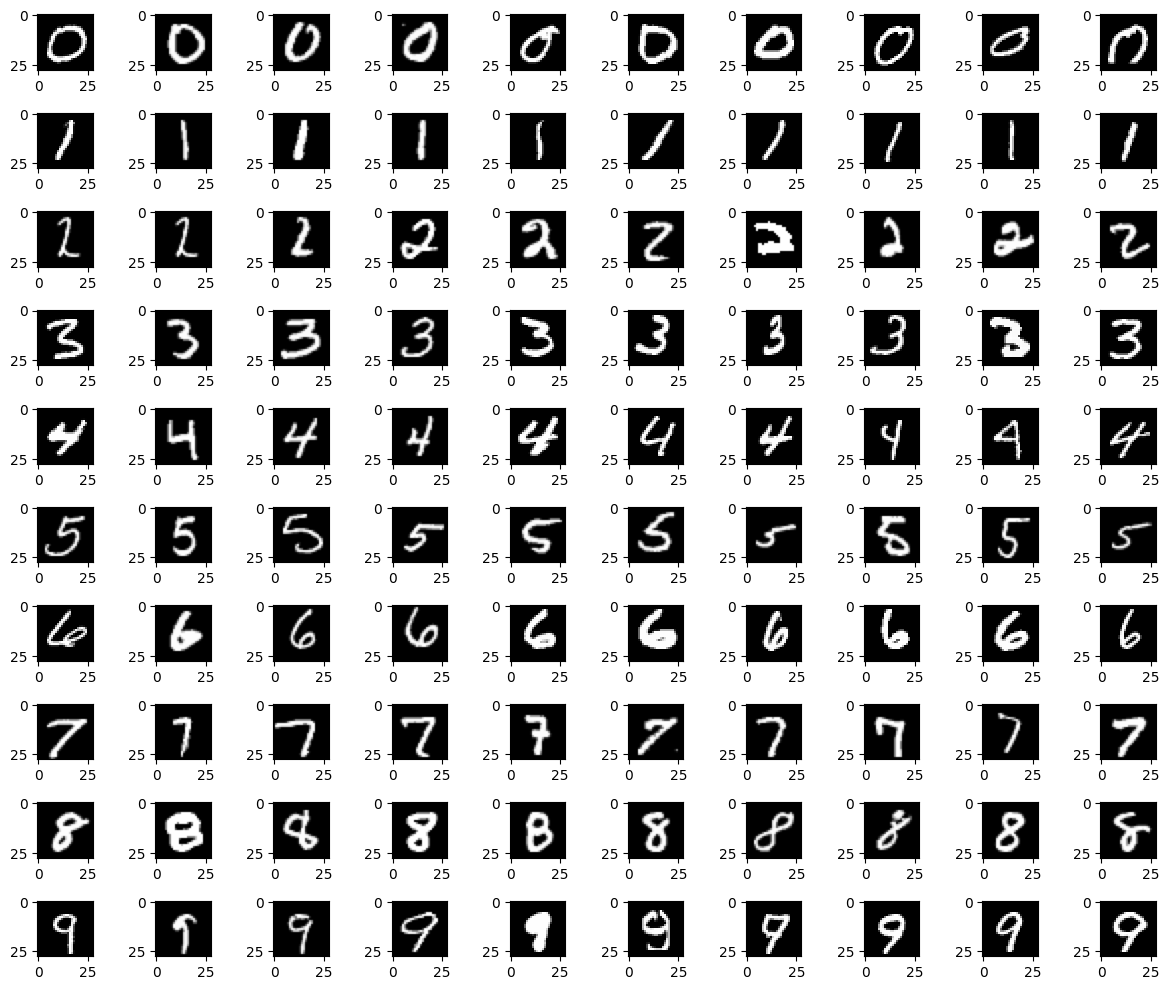

In [ ]:
#Visualizing some images for proper understanding (10x10 grid representing each unique image)
fig, ax = plt.subplots(len(target_classes), 10, figsize=(12,10))
for label_class, plot_row in enumerate(ax):
    #Add the labels for each cell
    label_x_rows = np.where(train_targets == label_class)[0] #Check where each target matches the label idx 0, 1, 2...
    for plot_cell in plot_row:
        idx = np.random.choice(label_x_rows)
        x,y = train_images[idx], train_targets[idx]
        plot_cell.imshow(x, cmap="gray")
plt.tight_layout()

In [ ]:
#Developing the custom dataset for MNIST called MNISTDataset
class MNISTDataset(Dataset):
     def __init__(self, x, y):
         #ensure both x and y can are of type Tensor
         if not (isinstance(x, torch.Tensor) and isinstance(y, torch.Tensor)):
            x = torch.Tensor(x)
            y = torch.Tensor(y)

         x = x.float() / 255 #normalize each of the images
         x = x.view(-1, 1, 28, 28) #Reshape the data for a CNN model
         self.x, self.y = x, y

     def __getitem__(self, idx):
         return self.x[idx].to(device), self.y[idx].to(device)

     def __len__(self):
         if len(self.x) == 0:
            return 0

         return len(self.x)

     def __str__(self):
         #String summary of the dataset data and targets
         return "Dataset length: {}\n Dataset target length: {}" \
                .format(len(self.x), len(self.y))

In [ ]:
#Creating an MLP model
#Model shape should be (batch, channel, width, height)
class MLPModel(nn.Module):
     def __init__(self):
         super().__init__()
         self.flatten = nn.Flatten() #flatten the data to the correct shape first
         self.fc1 = nn.Linear(28 * 28 * 1, 128)
         self.relu1 = nn.ReLU()
         self.fc2 = nn.Linear(128, 128)
         self.relu2 = nn.ReLU()
         self.out = nn.Linear(128, 10)

     def forward(self, x):
         x = self.flatten(x)
         x = self.relu1(self.fc1(x))
         x = self.relu2(self.fc2(x))
         return self.out(x)

In [ ]:
#Developing the Convolutional Neural Network Model
class CustomResNetModel(nn.Module): #Similar to ResNet18 but custom
     def __init__(self):
         super().__init__()
         self.layer1 = nn.Conv2d(1, 64, kernel_size = 7, stride = 2)
         self.maxPool = nn.MaxPool2d(2, stride = 2)
         self.layer2 = nn.Conv2d(64, 64, kernel_size = 3, padding = 1)
         self.layer3 = nn.Conv2d(64, 128, kernel_size = 3, padding = 1)
         self.layer4 = nn.Conv2d(128, 128, kernel_size = 3, padding = 1)
         self.layer5 = nn.Conv2d(128, 256, kernel_size = 3, padding = 1)
         self.layer6 = nn.Conv2d(256, 512, kernel_size = 3, padding = 1)
         self.layer7 = nn.Conv2d(512, 512, kernel_size = 3, padding = 1)
         self.avgPool = nn.AvgPool2d(2, stride = 2)
         self.flatten = nn.Flatten()
         self.out = nn.Linear(2048, 10)
         #TO DO - Add BatchNorm if required

     def forward(self, x):
         x = self.layer1(x)
         x = self.maxPool(x)
         x = self.layer2(x)
         x = self.layer3(x)
         x = self.layer4(x)
         x = self.layer5(x)
         x = self.layer6(x)
         x = self.layer7(x)
         x = self.flatten(self.avgPool(x))
         return self.out(x)

In [ ]:
def train_batch(x, y, model, opt, loss_fn):
    model.train() #activate train mode (good practice) for dropout
    pred = model(x)
    #calculate loss
    loss = loss_fn(pred, y)
    #update the gradients (backprop)
    loss.backward()
    #update the params
    opt.step()
    #Reset gradients
    opt.zero_grad()
    return loss.item()

In [ ]:
@torch.no_grad() #do not perform gradient tracking
def val_loss(x, y, model, loss_fn):
    model.eval() #ignore dropout, etc.
    pred = model(x)
    loss = loss_fn(pred, y)
    return loss.item()

In [ ]:
@torch.no_grad() #no gradient tracking
def accuracy_score(x, y, model):
    model.eval()
    pred = model(x)
    max_values, argmaxes = pred.max(-1)
    is_correct = argmaxes == y
    return is_correct.cpu().numpy().tolist()
    #TO DO ensure similar results with sklearn accuracy_report
    #Bonus: add the formula in text format below

In [ ]:
#Instantiate get_data function
def get_data(train_data, train_targets, val_data, val_targets, batch_size = 32):
    #Developing the datasets for training and validation
    train_dataset = MNISTDataset(train_data, train_targets)
    val_dataset = MNISTDataset(val_data, val_targets)
    #Developing the DataLoaders
    train_dl = DataLoader(train_dataset, batch_size=batch_size, shuffle = True)
    val_dl = DataLoader(val_dataset, batch_size=batch_size, shuffle = False)

    return train_dl, val_dl

In [ ]:
def get_model(model_type : str, learning_rate : float = 1e-3):
    if model_type == "mlp":
       model = MLPModel()
    elif model_type == "resnet":
       model = CustomResNetModel()
    else:
       raise Exception("Invalid model")
    loss_fn = nn.CrossEntropyLoss()
    optimizer = AdamW(model.parameters(), lr=learning_rate)
    return model.to(device), loss_fn, optimizer

In [ ]:
train_dl, val_dl = get_data(train_images, train_targets, val_images, val_targets)

In [ ]:
model_res, loss_fn, optimizer_res = get_model("resnet")

In [ ]:
model_mlp, loss_fn, optimizer_mlp = get_model("mlp")

In [ ]:
from torchsummary import summary

In [ ]:
#MLP model summary
summary(model_mlp, torch.zeros(1, 28, 28).shape)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                  [-1, 128]         100,480
              ReLU-3                  [-1, 128]               0
            Linear-4                  [-1, 128]          16,512
              ReLU-5                  [-1, 128]               0
            Linear-6                   [-1, 10]           1,290
Total params: 118,282
Trainable params: 118,282
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.45
Estimated Total Size (MB): 0.46
----------------------------------------------------------------


In [ ]:
#Summarizing the MLP model (two layers)
summary(model_res, torch.zeros(1, 28, 28).shape)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 11, 11]           3,200
         MaxPool2d-2             [-1, 64, 5, 5]               0
            Conv2d-3             [-1, 64, 5, 5]          36,928
            Conv2d-4            [-1, 128, 5, 5]          73,856
            Conv2d-5            [-1, 128, 5, 5]         147,584
            Conv2d-6            [-1, 256, 5, 5]         295,168
            Conv2d-7            [-1, 512, 5, 5]       1,180,160
            Conv2d-8            [-1, 512, 5, 5]       2,359,808
         AvgPool2d-9            [-1, 512, 2, 2]               0
          Flatten-10                 [-1, 2048]               0
           Linear-11                   [-1, 10]          20,490
Total params: 4,117,194
Trainable params: 4,117,194
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forw

In [ ]:
#Developing the training loop
def train_model(train_dl, val_dl,
                model, optimizer,
                loss_fn, num_epochs
                ):
    train_losses, train_accuracies = [], []
    val_losses, val_accuracies = [], []
    for epoch in range(num_epochs):
        train_epoch_loss, train_epoch_accuracy = [],[]
        for (train_images, train_targets) in iter(train_dl):
             batch_loss = train_batch(train_images, train_targets, model, optimizer, loss_fn)
             train_epoch_loss.append(batch_loss)
        mean_epoch_loss = np.array(train_epoch_loss).mean()
        for (train_images, train_targets) in iter(train_dl):
            batch_accuracy = accuracy_score(train_images, train_targets, model)
            train_epoch_accuracy.extend(batch_accuracy)
        epoch_accuracy = np.array(train_epoch_accuracy).mean() #calculate the accuracy
        for (val_images, val_targets) in iter(val_dl):
             batch_val_loss = val_loss(val_images, val_targets, model, loss_fn) #update the val loss per batch
             batch_val_accuracy = accuracy_score(val_images, val_targets, model)
        val_epoch_accuracy = np.array(batch_val_accuracy).mean() #val accuracy after each epoch

        train_losses.append(mean_epoch_loss)
        train_accuracies.append(epoch_accuracy)
        val_losses.append(batch_val_loss)
        val_accuracies.append(val_epoch_accuracy)

        print("Epoch - {} | Training Loss: {:.3f}  | Training Accuracy: {:.3f} | Val Loss: {:.3f} | Val Accuracy: {:.3f}" \
               .format(epoch, mean_epoch_loss, epoch_accuracy, batch_val_loss, val_epoch_accuracy))
    epochs = np.arange(num_epochs)+1
    plt.figure(figsize=(10, 5))
    plt.subplot(121)
    plt.title('Training Loss per Epoch')
    plt.plot(epochs, train_losses, label = 'Train Loss', marker = 'o', color='blue', linestyle='None')
    plt.plot(epochs, val_losses, label = 'Val Loss', color = 'red')
    plt.xlabel('Epoch')
    plt.ylabel('Train Losses')
    plt.legend()

    plt.subplot(122)
    plt.title('Validation Loss per Epoch')
    plt.plot(epochs, train_accuracies, label = 'Train Accuracy', marker = 'o', color='blue', linestyle='None')
    plt.plot(epochs, val_accuracies, label = 'Validation Accuracy', color = 'red')
    plt.xlabel('Epoch')
    plt.ylabel('Validation Accuracies')
    plt.legend()

    plt.tight_layout()

Epoch - 0 | Training Loss: 0.277  | Training Accuracy: 0.959 | Val Loss: 0.013 | Val Accuracy: 1.000
Epoch - 1 | Training Loss: 0.113  | Training Accuracy: 0.978 | Val Loss: 0.002 | Val Accuracy: 1.000
Epoch - 2 | Training Loss: 0.077  | Training Accuracy: 0.980 | Val Loss: 0.015 | Val Accuracy: 1.000
Epoch - 3 | Training Loss: 0.058  | Training Accuracy: 0.985 | Val Loss: 0.001 | Val Accuracy: 1.000
Epoch - 4 | Training Loss: 0.046  | Training Accuracy: 0.990 | Val Loss: 0.001 | Val Accuracy: 1.000
Epoch - 5 | Training Loss: 0.037  | Training Accuracy: 0.986 | Val Loss: 0.000 | Val Accuracy: 1.000
Epoch - 6 | Training Loss: 0.031  | Training Accuracy: 0.988 | Val Loss: 0.000 | Val Accuracy: 1.000
Epoch - 7 | Training Loss: 0.028  | Training Accuracy: 0.989 | Val Loss: 0.000 | Val Accuracy: 1.000
Epoch - 8 | Training Loss: 0.024  | Training Accuracy: 0.995 | Val Loss: 0.000 | Val Accuracy: 1.000
Epoch - 9 | Training Loss: 0.021  | Training Accuracy: 0.995 | Val Loss: 0.000 | Val Accura

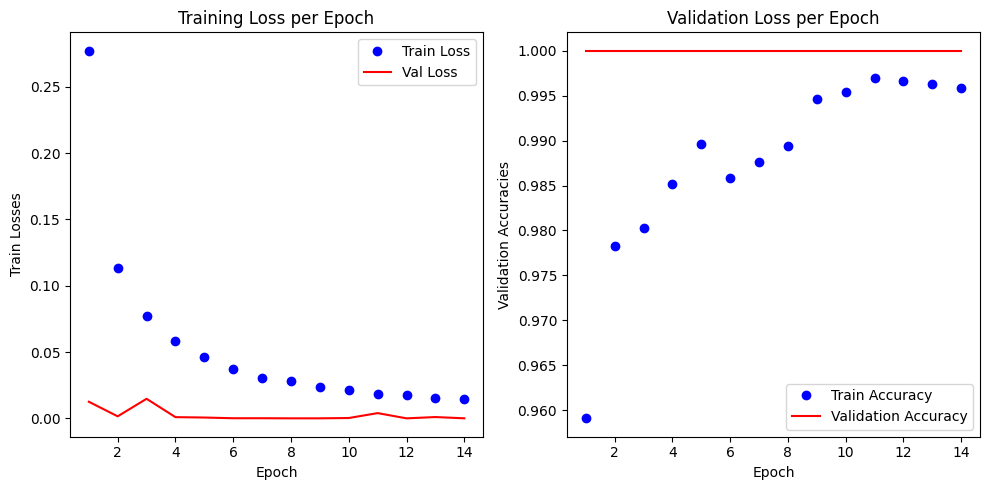

In [ ]:
#Training and evaluating the MLP model
train_model(
    train_dl=train_dl,
    val_dl=val_dl,
    model=model_mlp,
    optimizer=optimizer_mlp,
    loss_fn=loss_fn,
    num_epochs=14
)

Epoch - 0 | Training Loss: 148.831  | Training Accuracy: 0.903 | Val Loss: 38.331 | Val Accuracy: 0.938
Epoch - 1 | Training Loss: 4.636  | Training Accuracy: 0.961 | Val Loss: 0.000 | Val Accuracy: 1.000
Epoch - 2 | Training Loss: 0.611  | Training Accuracy: 0.966 | Val Loss: 0.000 | Val Accuracy: 1.000
Epoch - 3 | Training Loss: 0.261  | Training Accuracy: 0.967 | Val Loss: 0.000 | Val Accuracy: 1.000
Epoch - 4 | Training Loss: 0.151  | Training Accuracy: 0.975 | Val Loss: 0.000 | Val Accuracy: 1.000
Epoch - 5 | Training Loss: 0.107  | Training Accuracy: 0.976 | Val Loss: 0.000 | Val Accuracy: 1.000
Epoch - 6 | Training Loss: 0.094  | Training Accuracy: 0.977 | Val Loss: 0.001 | Val Accuracy: 1.000
Epoch - 7 | Training Loss: 0.099  | Training Accuracy: 0.961 | Val Loss: 0.005 | Val Accuracy: 1.000
Epoch - 8 | Training Loss: 214.248  | Training Accuracy: 0.954 | Val Loss: 0.000 | Val Accuracy: 1.000
Epoch - 9 | Training Loss: 1.856  | Training Accuracy: 0.965 | Val Loss: 0.000 | Val A

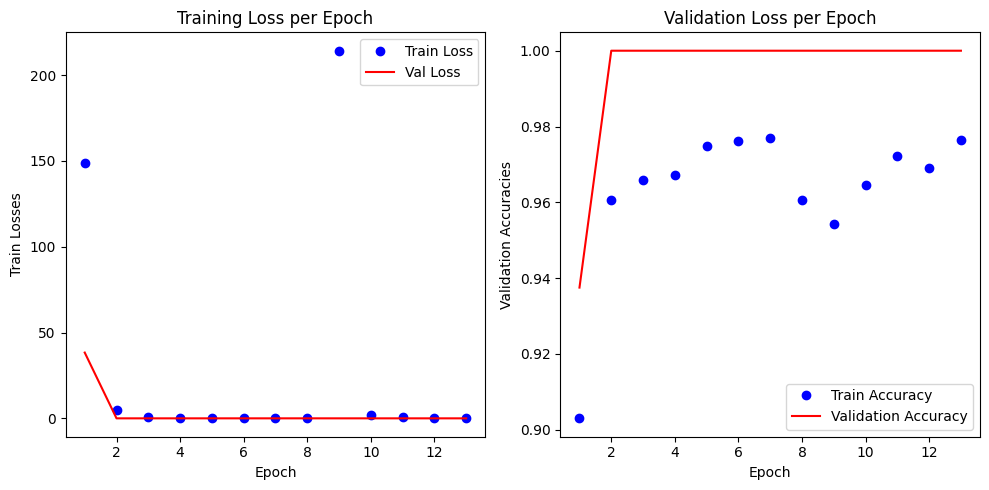

In [ ]:
#Training and evaluating the custom resnet model
train_model(
    train_dl=train_dl,
    val_dl=val_dl,
    model=model_res,
    optimizer=optimizer_res,
    loss_fn=loss_fn,
    num_epochs=13
)

Paper calculations

In [ ]:
#Creating a standard CNN model
input_image = torch.randn(1, 28, 28, dtype=torch.float)

In [ ]:
input_image.shape

torch.Size([1, 28, 28])

In [ ]:

# x = input_image.unsqueeze(0) # Add a channel dimension, making it (1, 1, 28, 28)
x = rand_image
print(x.shape)
kernel = nn.Conv2d(1, 64, kernel_size = 7, stride = 2)
x = kernel(x)
max_res = nn.MaxPool2d(2, stride = 2)
x = max_res(x)
kernel2 = nn.Conv2d(64, 64, kernel_size = 3, padding = 1)
x = kernel2(x)
layer3 = nn.Conv2d(64, 128, kernel_size = 3, padding = 1)
x = layer3(x)
layer4 = nn.Conv2d(128, 128, kernel_size = 3, padding = 1)
x = layer4(x)
layer5 = nn.Conv2d(128, 256, kernel_size = 3, padding = 1)
x = layer5(x)
layer6 = nn.Conv2d(256, 512, kernel_size = 3, padding = 1)
x = layer6(x)
layer7 = nn.Conv2d(512, 512, kernel_size = 3, padding = 1)
x = layer7(x)
avg_pool = nn.AvgPool2d(2, stride = 2)
x = avg_pool(x)
flatten = nn.Flatten()
x = flatten(x)
out = nn.Linear(2048, 10)
x = out(x)
x.shape

torch.Size([1, 1, 28, 28])


torch.Size([1, 10])